# 决策回归树与集成算法
## 决策树预测圆的轨迹 

手写决策回归树

In [8]:
import numpy as np
import sys
from loguru import logger
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
import graphviz
import scienceplots
plt.style.use(['nature', 'vibrant']) # 或者 'ieee', 'nature'
from matplotlib import font_manager

font_path="/home/lanshi/.local/share/fonts/SourceHanSerifSC-Regular.otf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False


logger.remove()

logger.add(
    sink=sys.stderr,
    level="INFO",
    format="<green>{time:YYYY-MM-DD HH:mm:ss.SSS}</green> | "
            "<level>{level:<8}</level> | "
            "<cyan>{name}</cyan>:<cyan>{function}</cyan>:<cyan>{line}</cyan> - "
            "<level>{message}</level>",
    colorize=True
)
logger.info(plt.rcParams['font.family'])

2026-05-26 21:59:32.499 | INFO     | __main__:<module>:33 - ['Source Han Serif SC']


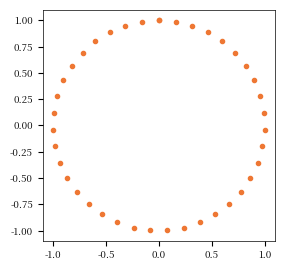

In [9]:
# 模拟数据
X=np.linspace(0,2*np.pi,40).reshape(-1,1)
X_test=np.linspace(0,2*np.pi,187).reshape(-1,1)
y=np.c_[np.sin(X),np.cos(X)]
plt.figure(figsize=(3,3))
plt.scatter(y[:,0],y[:,1])

In [10]:
logger.info(X.shape)
logger.info(X_test.shape)
logger.info(y.shape)


2026-05-26 21:59:32.550 | INFO     | __main__:<module>:1 - (40, 1)
2026-05-26 21:59:32.550 | INFO     | __main__:<module>:2 - (187, 1)
2026-05-26 21:59:32.550 | INFO     | __main__:<module>:3 - (40, 2)


## 计算未分裂时 整体MSE

In [11]:
mse=((y-y.mean(axis=0))**2).mean()
logger.info(f"未分裂时 MSE:{mse}")

2026-05-26 21:59:32.554 | INFO     | __main__:<module>:2 - 未分裂时 MSE:0.4996875


In [12]:
# 2、根据分裂标准X[0] <= 3.142，计算分裂后的MSE：
cond=X<=3.142
part1=y[cond.reshape(-1)]
part2=y[~(cond.reshape(-1))]
mse1=((part1-part1.mean(axis=0))**2).mean()
mse2=((part2-part2.mean(axis=0))**2).mean()
logger.info(f"mse1:{mse1}\n mse2:{mse2}")



2026-05-26 21:59:32.558 | INFO     | __main__:<module>:7 - mse1:0.3072588991283228
 mse2:0.3072588991283228


In [13]:
split_res={}
mse_res=[]
mse_lower=0.5
for i in trange(len(X)-1):
    split=round(X[i:i+2].mean(),3)
    cond=X<=split
    part1=y[(cond.reshape(-1))]
    part2=y[~(cond.reshape(-1))]
    mse1=((part1-part1.mean(axis=0))**2).mean()
    mse2=((part2-part2.mean(axis=0))**2).mean()
    mse=mse1*len(part1)/cond.size+mse2*len(part2)/cond.size
    mse_res.append(mse)
    if mse<mse_lower:
        split_res.clear()
        split_res[split]=[i,mse]
        mse_lower=mse
logger.info(f"bese:{split_res}")


100%|██████████| 39/39 [00:00<00:00, 46523.85it/s]
2026-05-26 22:01:44.801 | INFO     | __main__:<module>:17 - bese:{np.float64(3.142): [19, np.float64(0.3072588991283228)]}


## 集成算法